In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader



In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/saqibsafdar11/Predicting-Listing-Gains-in-the-Indian-IPO-Market/refs/heads/main/Indian_IPO_Market_Data.csv')

print("Top 5 rows:")
print(df.head())
print("Bottom 5 rows:")
print(df.tail())

print(f"There are {df.shape[0]} IPOs and {df.shape[1]} attributes for each IPO")

print("Column Information:")
print(df.info())


print("The target variable is Listing_Gains_Percent column and its summary is:")
print(df['Listing_Gains_Percent'].describe())

print("Sumamry statistics for all the numeric columns:")
print(df.describe())

df_original = df.copy()

Top 5 rows:
      Date           IPOName  Issue_Size  Subscription_QIB  Subscription_HNI  \
0  03/02/10    Infinite Comp      189.80             48.44            106.02   
1  08/02/10    Jubilant Food      328.70             59.39             51.95   
2  15/02/10    Syncom Health       56.25              0.99             16.60   
3  15/02/10  Vascon Engineer      199.80              1.12              3.65   
4  19/02/10      Thangamayil        0.00              0.52              1.52   

   Subscription_RII  Subscription_Total  Issue_Price  Listing_Gains_Percent  
0             11.08               43.22          165                  11.82  
1              3.79               31.11          145                 -84.21  
2              6.25                5.17           75                  17.13  
3              0.62                1.22          165                 -11.28  
4              2.26                1.12           75                  -5.20  
Bottom 5 rows:
        Date           I

### Transforming the target column
As we wish to find if the IPO will be profitable or not when listed, we dont require a continuous value in this column. We just need a binary value, where 1 means the IPO will be profitable and 0 means it will result in loss.

In [ ]:
df['Listing_Gains_Profit'] = np.where(df['Listing_Gains_Percent'] >0, 1, 0)
print("Top 5 rows showing original target vs the transformed target:")
print(df[['Listing_Gains_Percent', 'Listing_Gains_Profit']].head())

Top 5 rows showing original target vs the transformed target:
   Listing_Gains_Percent  Listing_Gains_Profit
0                  11.82                     1
1                 -84.21                     0
2                  17.13                     1
3                 -11.28                     0
4                  -5.20                     0


### Target variable distribution

In [ ]:
print("Count of gains and losses:")
target_counts = df['Listing_Gains_Profit'].value_counts()
print(target_counts)

target_percentages = df['Listing_Gains_Profit'].value_counts(normalize=True) * 100
print("\nIn percentages:")
print(f"\tProfitable IPOs (1): {target_percentages[1]:.2f}%")
print(f"\tLoss IPOs (0): {target_percentages[0]:.2f}%")

# profitable_percentage = (df['Listing_Gains_Profit'] == 1).mean() * 100


Count of gains and losses:
Listing_Gains_Profit
1    174
0    145
Name: count, dtype: int64

In percentages:
	Profitable IPOs (1): 54.55%
	Loss IPOs (0): 45.45%


We can see that our target is decently balanced.

## Comparison of profitable v/s non-profitable IPOs:

### Average gain or loss

In [ ]:
print(f"Average listing gain of profitable IPOS: {df[df['Listing_Gains_Profit']==1]['Listing_Gains_Percent'].mean():.2f}%")
print(f"Average listing loss of non profitable IPOS: {df[df['Listing_Gains_Profit']==0]['Listing_Gains_Percent'].mean():.2f}%")

Average listing gain of profitable IPOS: 33.99%
Average listing loss of non profitable IPOS: -30.36%


###Max gain or loss

In [ ]:
print(f"Largest gain: {df['Listing_Gains_Percent'].max():.2f}%")
print(f"Largest loss: {df['Listing_Gains_Percent'].min():.2f}%")

Largest gain: 270.40%
Largest loss: -97.15%


We will remove features that do not contribute in predicting the target variable.
The columns we will exclude are:
  - IPOName
  - Date
  - Listing_Gains_Percent: We already created 'Listing_Gains_Profit' from this
  - Listing_Gains_Profit: This is our target column and must not be used for training

In [ ]:
print("All columns in the dataset: ")
print(list(df.columns))

exclude_columns = ['IPOName', 'Date ', 'Listing_Gains_Percent', 'Listing_Gains_Profit']
required_features = [col for col in df.columns if col not in exclude_columns]
print(f"\nRequred columns: {required_features}")
print(f"Number of features: {len(required_features)}")


All columns in the dataset: 
['Date ', 'IPOName', 'Issue_Size', 'Subscription_QIB', 'Subscription_HNI', 'Subscription_RII', 'Subscription_Total', 'Issue_Price', 'Listing_Gains_Percent', 'Listing_Gains_Profit']

Requred columns: ['Issue_Size', 'Subscription_QIB', 'Subscription_HNI', 'Subscription_RII', 'Subscription_Total', 'Issue_Price']
Number of features: 6


## Visual representation of data

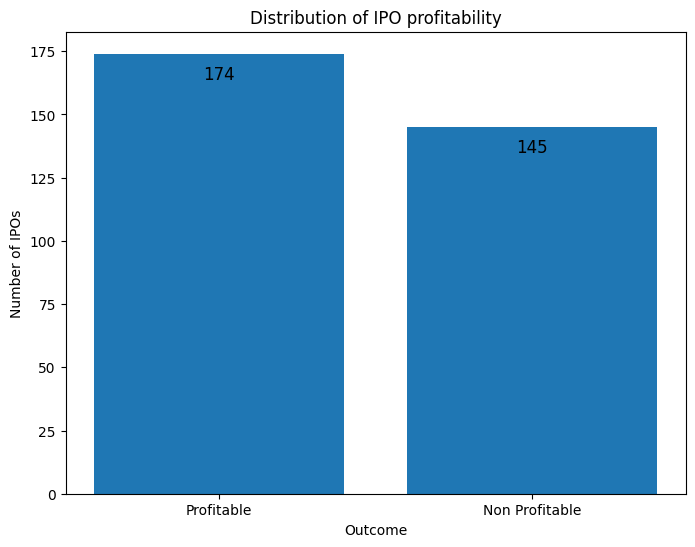

In [ ]:
# visualize target distribution
plt.figure(figsize=(8,6))

target_counts = df['Listing_Gains_Profit'].value_counts()
plt.bar(['Profitable', 'Non Profitable'], target_counts.values)
plt.title('Distribution of IPO profitability')
plt.ylabel("Number of IPOs")
plt.xlabel('Outcome')

# to put the actual numbers on the bar
for i, count in enumerate(target_counts.values):
  plt.text(i, count - 10, str(count), ha='center', fontsize=12)

plt.show()


The required feature columns:
Issue_Size
Subscription_QIB
Subscription_HNI
Subscription_RII
Subscription_Total
Issue_Price


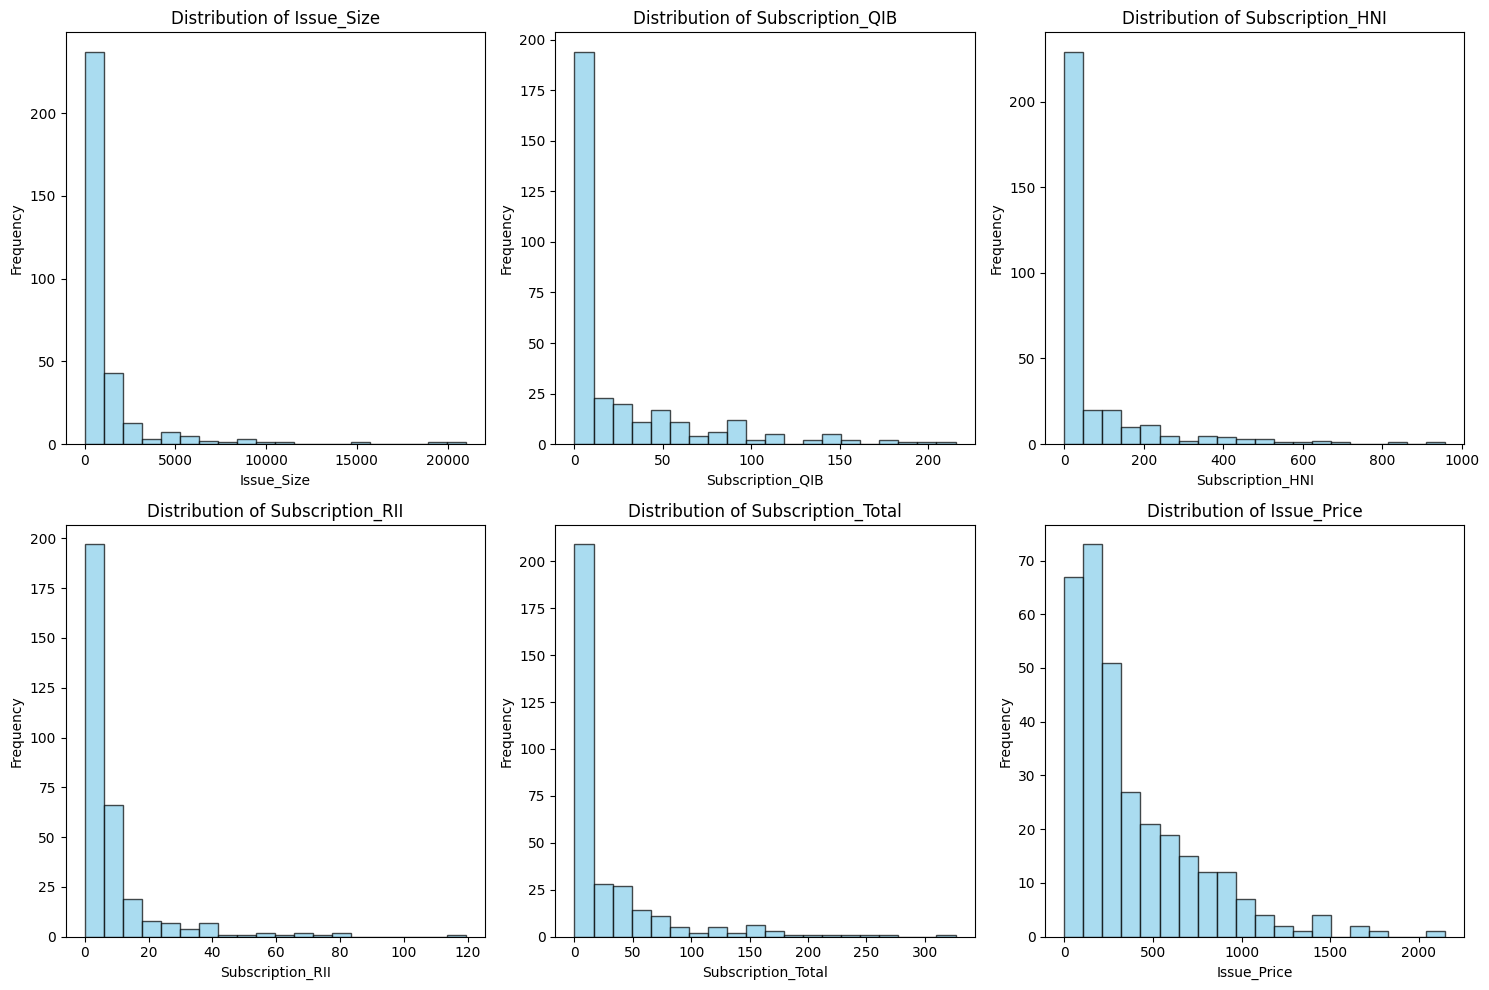

In [ ]:
print("The required feature columns:")
for col in required_features:
  print(f"{col}")

# visualizing the distribution of each feature
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(required_features):
  axes[i].hist(df[column].dropna(), bins=20, alpha=0.7, color='skyblue', edgecolor = 'black')
  axes[i].set_title(f"Distribution of {column}")
  axes[i].set_xlabel(column)
  axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Except 'Issue_Price' column the values of other columns are clustered heavily in the first bin and then show sharp decrease as we move right.
All the graphs are right skewed here.

Another thing to notice is the sparse values present in the right part of the graphs, these are outliers that will affect the learning of our model. This can be solved by scaling.

### How do the features affect the IPO success?

Let's find out by comparing the profitable and non profitable IPOs across all features.

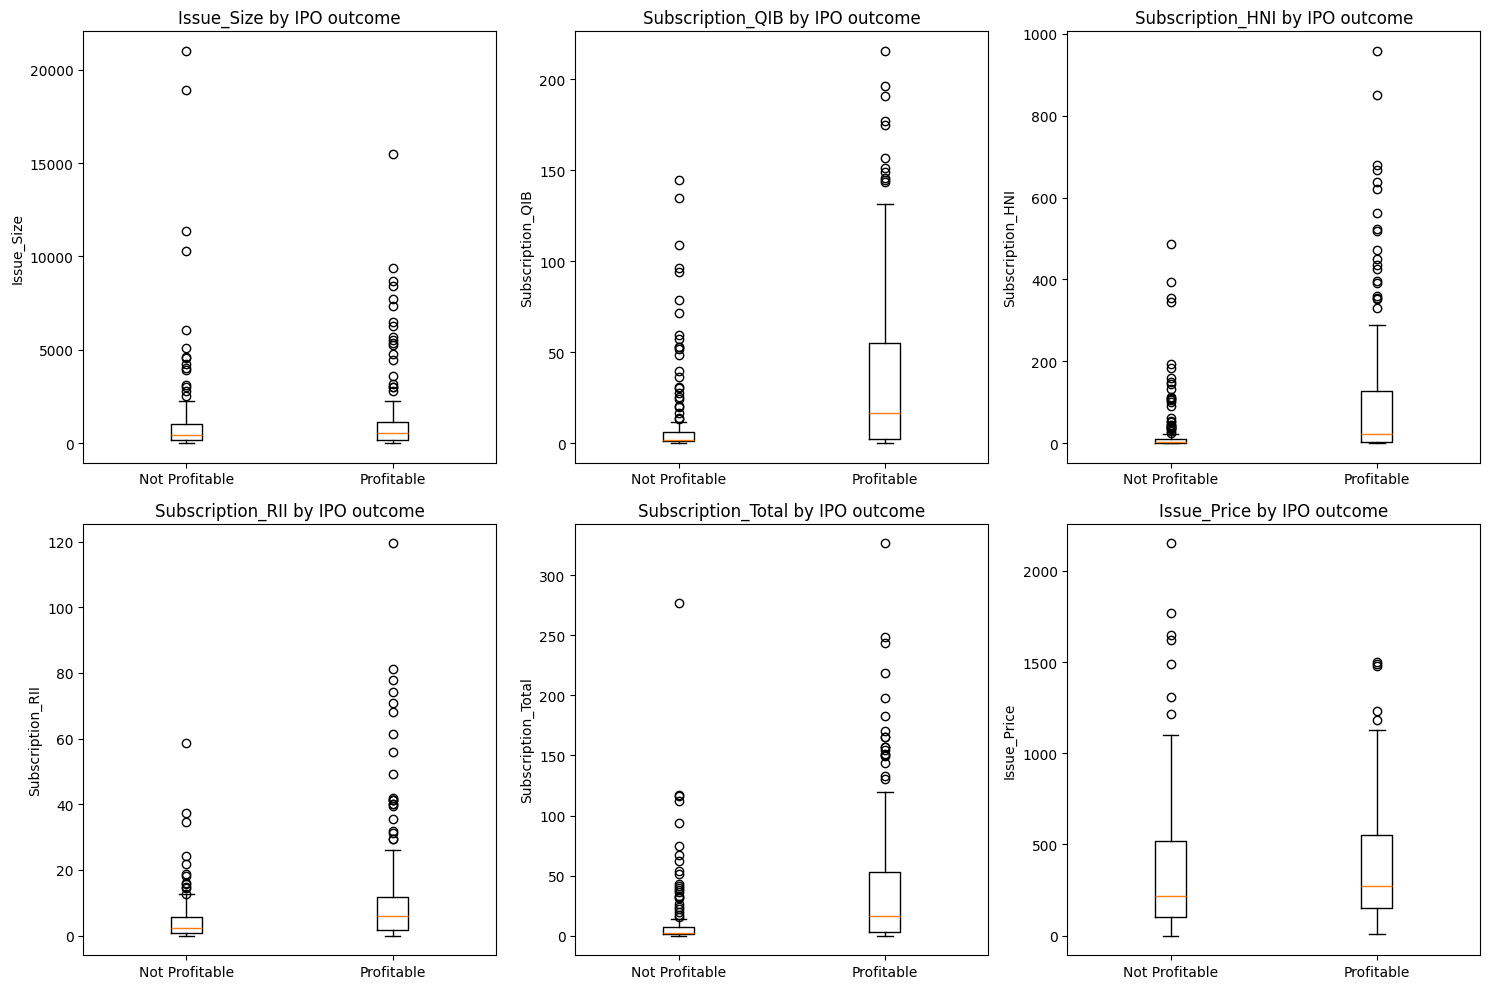

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

for i, column in enumerate(required_features):
  profitable_data = df[df['Listing_Gains_Profit'] == 1][column]
  non_profitable_data = df[df['Listing_Gains_Profit'] == 0][column]

  axes[i].boxplot([non_profitable_data.dropna() , profitable_data.dropna()],

                  tick_labels = ['Not Profitable', 'Profitable'])
  axes[i].set_title(f"{column} by IPO outcome")
  axes[i].set_ylabel(column)

plt.tight_layout()
plt.show()

From the above we can conclude that, 'Issue_Size' and 'Issue_Price' are not deciding factors for the profitability of an ipo.
However the Subscription metrics clearly show that profitable IPOs have higher subscription rates.

### Finding relationship between features

we do this by finding the correlation matrix and heatmap.

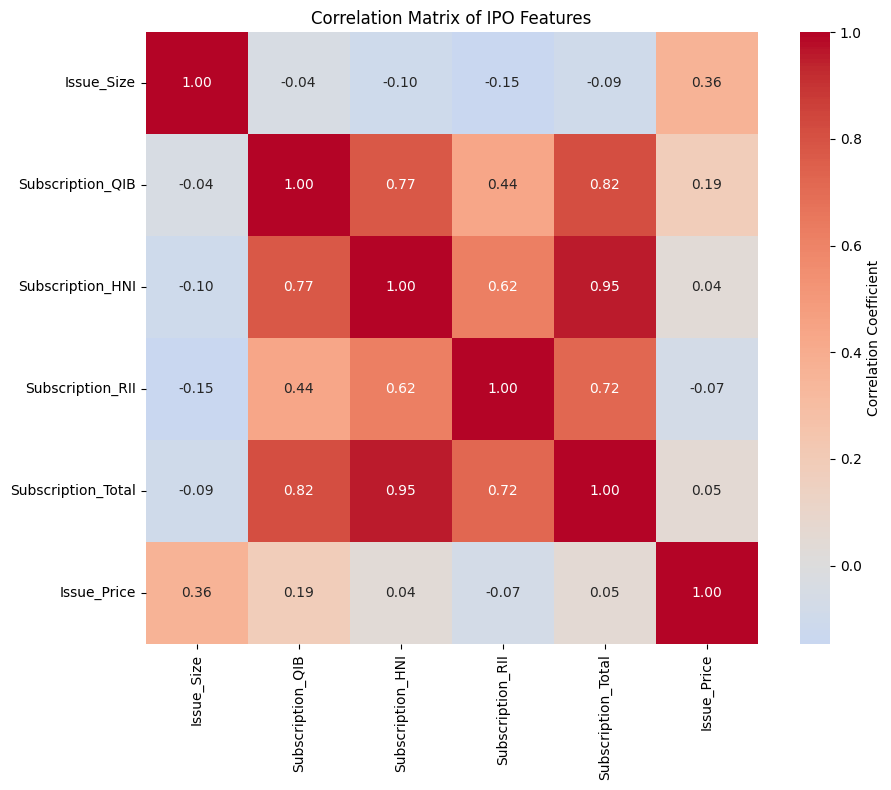

Correlation with the profitability of IPO:
Subscription_QIB      0.323499
Subscription_Total    0.283340
Subscription_HNI      0.271879
Subscription_RII      0.240842
Issue_Price           0.039548
Issue_Size            0.004717
Name: Listing_Gains_Profit, dtype: float64


In [ ]:
numeric_features = df[required_features].select_dtypes(include=[np.number])
correlation_matrix = numeric_features.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Correlation Matrix of IPO Features')
plt.tight_layout()
plt.show()

### the features that correlate the most with the target
target_correlations = df[required_features + ['Listing_Gains_Profit']].corr()['Listing_Gains_Profit'].sort_values(ascending=False)
print("Correlation with the profitability of IPO:")
print(target_correlations[1:]) # to exclude the target's correlation with itself


Although Issue_Price and Issue_Size have weak correlation with success, we should not remove them. As correlation only captures linear relationships between individual features and target. However neural networks can find more complex patterns for the interactions between features.

We will only remove Subscription_Total column as it is just the sum of individual subscription components (Subscription_HNI, Subscription_RII, Subscription_QIB). This is will remove the redundancy that may confuse the model.


In [ ]:
feature_columns = ['Subscription_QIB', 'Subscription_HNI', 'Subscription_RII', 'Issue_Price', 'Issue_Size']

## Setting up the data for training

In [ ]:
X = df[feature_columns].copy()
y = df['Listing_Gains_Profit'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")



Feature matrix shape: (319, 5)
Target vector shape: (319,)


### Splitting data

1. split data into temp and test data (test size = 20%)
2. Then split 75% of the temp data into training and the remaining into validation i.e 25%

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size = 0.2, stratify = y, random_state=42
)

print(f"After split 1:")
print(f"Temp data: {X_temp.shape[0]} samples")
print(f"Test data: {X_test.shape[0]} samples")
print(f"Test target distribution: {y_test.mean():.1%} profitable")

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size = 0.25, # 25% * 80(remaining) = 20
    stratify=y_temp,
    random_state = 42
)
print()
print(f"After split 2:")
print(f"Training: {X_train.shape[0]} samples ({X_train.shape[0]/len(df):.1%})")
print(f"Validation: {X_val.shape[0]} samples ({X_val.shape[0]/len(df):.1%})")
print(f"Test: {X_test.shape[0]} samples ({X_test.shape[0]/len(df):.1%})")

print()
print(f"Target distributions:")
print(f"Training: {y_train.mean():.1%} profitable")
print(f"Validation: {y_val.mean():.1%} profitable")
print(f"Test: {y_test.mean():.1%} profitable")


After split 1:
Temp data: 255 samples
Test data: 64 samples
Test target distribution: 54.7% profitable

After split 2:
Training: 191 samples (59.9%)
Validation: 64 samples (20.1%)
Test: 64 samples (20.1%)

Target distributions:
Training: 54.5% profitable
Validation: 54.7% profitable
Test: 54.7% profitable


### Scaling features

As our features are on different scales, for our model to learn effectively from all features equally, we need to standarize our features. This can be done through scaling the features. Scaling converts the data so that its mean is near 0 and standard deviation near 1.

NOTE: We fit the scaler only on the training data, then use the scaling parameters to transform the validation and test sets. This is similar to real world conditions where we know only histroical data when scaling new IPOs for predicting.

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)

print("Parameters learned from scaling the training data:")
print(f"feature means: {scaler.mean_}")
print(f"feature standard deviations: {scaler.scale_}")

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# to keep our column names we will convert back to dataframes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=feature_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_columns)

print("Scaled dataset shapes:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled: {X_val_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")


Parameters learned from scaling the training data:
feature means: [  26.4952356    73.29701571    8.02041885  380.59162304 1071.6808377 ]
feature standard deviations: [  41.48012514  148.75074      12.11881169  348.99351279 2084.1555454 ]
Scaled dataset shapes:
X_train_scaled: (191, 5)
X_val_scaled: (64, 5)
X_test_scaled: (64, 5)


### Verification of our scaling

The training data after scaling should have a mean near to 0 and standard deviation near 1


In [ ]:
print(f"Means: {X_train_scaled.mean().round(3).values}")
print(f"Standard Deviations: {X_train_scaled.std().round(3).values}")

# values will be different a little
print(f"\n Validation data after scaling: ")
print(f"Means: {X_val_scaled.mean().round(3).values}")

print(f"\n Test data after scaling: ")
print(f"Means: {X_test_scaled.mean().round(3).values}")

Means: [0. 0. 0. 0. 0.]
Standard Deviations: [1.003 1.003 1.003 1.003 1.003]

 Validation data after scaling: 
Means: [-0.026 -0.114  0.069 -0.243  0.025]

 Test data after scaling: 
Means: [-0.071  0.007  0.154  0.165  0.265]


### Convert to pytorch tensors

As pytorch works with tensors rather than dataframes, we will be converting our dataframes into tensors

In [ ]:
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)


print("Tensor shapes:")
print(f"X_train: {X_train_tensor.shape}")
print(f"y_train: {y_train_tensor.shape}")
print(f"X_val: {X_val_tensor.shape}")
print(f"y_val: {y_val_tensor.shape}")
print(f"X_test: {X_test_tensor.shape}")
print(f"y_test: {y_test_tensor.shape}")

Tensor shapes:
X_train: torch.Size([191, 5])
y_train: torch.Size([191])
X_val: torch.Size([64, 5])
y_val: torch.Size([64])
X_test: torch.Size([64, 5])
y_test: torch.Size([64])


### Creating datasets

We need to pair up our features with their corresponding targets. We will use TensorDataset that creates a collection of items where each item contains both the features and the target for an IPO

In [ ]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

print("Training dataset: {len(train_dataset)} samples")
print("Validation dataset: {len(val_dataset)} samples")
print("Test dataset: {len(test_dataset)} samples")



sample_features, sample_target = train_dataset[0]
print(f"Shape of features: {sample_features.shape}")
print(f"Target: {sample_target.item()}")

Training dataset: {len(train_dataset)} samples
Validation dataset: {len(val_dataset)} samples
Test dataset: {len(test_dataset)} samples
Shape of features: torch.Size([5])
Target: 1.0


### Setting up DataLoaders

We will shuffle only the training data as our model will see different combinations of the IPOs in every epoch which will help it in learning patters.
We will not shuffle the validation data as we want consistent and reproducible results when evaluation performance

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


print("Dataloaders created.")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Dataloaders created.
Training batches: 12
Validation batches: 4
Test batches: 4


### Verifying that our data pipeline is working.

In [ ]:
for batch_features, batch_targets in train_loader:
  print("Sample training batch: ")
  print(f"batch features shape: {batch_features.shape}")
  print(f"batch targets shape: {batch_targets.shape}")
  print(f"features dtype: {batch_features.dtype}")
  print(f"targets dtype: {batch_targets.dtype}")

  print(f"Target values in batch: {batch_targets.tolist()}")
  print(f"profitable ipos in batch: {(batch_targets ==1).sum().item()}/{len(batch_targets)}")

  break # we wish to see only the first batch

Sample training batch: 
batch features shape: torch.Size([16, 5])
batch targets shape: torch.Size([16])
features dtype: torch.float32
targets dtype: torch.float32
Target values in batch: [1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0]
profitable ipos in batch: 9/16


### Neural Network Architecture

Using a funnel approach where we start wide to capture many different patterns, and then narrow down as we focus on the most important ones.

In [ ]:
input_size = X_train_tensor.shape[1] # no. of features
print(f"Our model needs to handle {input_size} input features")

model = nn.Sequential(
    nn.Linear(input_size, 64),
    nn.ReLU(),

    nn.Linear(64, 32),
    nn.ReLU(),

    nn.Linear(32, 16),
    nn.ReLU(),

    nn.Linear(16,1),
    nn.Sigmoid()
)

print("Model created.")
print(model)

Our model needs to handle 5 input features
Model created.
Sequential(
  (0): Linear(in_features=5, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=1, bias=True)
  (7): Sigmoid()
)


### Inspecting the model
Each of the linear layer is a collection of neurons that takes inputs, multiplies them with learned weights and adds bias and then pass the result to the activation function.function.
ReLU (rectified linear unit) is an activation function that adds non-linearity to the model. It helps the network learn complex, non-linear relationships between the features and the success of the IPOs.

ReLU: max(0, value) i.e it keeps non-negative values intact and converts negative values into zero

In [ ]:
total_params = sum(param.numel() for param in model.parameters())
trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)

print(f"Total params: {total_params}")
print(f"Trainable params: {trainable_params}")

print("Parameter breakdown by layer:")
for i, layer in enumerate(model):
  if isinstance(layer, nn.Linear):
    layer_params = sum(param.numel() for param in layer.parameters())
    print(f" Layer {i}: {layer_params:,} parameters")

Total params: 3009
Trainable params: 3009
Parameter breakdown by layer:
 Layer 0: 384 parameters
 Layer 2: 2,080 parameters
 Layer 4: 528 parameters
 Layer 6: 17 parameters


### Testing the model structure
Making sure our model can process the data correctly.

In [ ]:
model.eval() # to put in eval mode for testing
with torch.no_grad():
  for batch_features, batch_targets in train_loader:
    test_outputs = model(batch_features)

    print(f"input batch shape: {batch_features.shape}")
    print(f"output batch shape: {test_outputs.shape}")
    print(f"sample predictions: {test_outputs.squeeze()[:5].tolist()}")
    print(f"sample actual targets: {batch_targets[:5].tolist()}")
    break



input batch shape: torch.Size([16, 5])
output batch shape: torch.Size([16, 1])
sample predictions: [0.493656188249588, 0.49456197023391724, 0.4989249110221863, 0.49521154165267944, 0.4985799789428711]
sample actual targets: [1.0, 0.0, 0.0, 0.0, 0.0]


### loss function and optimizer

In [ ]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.00075)

train_accuracies = []
val_accuracies = []

### Main training loop

In [ ]:
epochs = 100
for epoch in range(epochs):
  model.train()

  for batch_features, batch_targets in train_loader:
    optimizer.zero_grad()
    outputs = model(batch_features).squeeze()
    loss = criterion(outputs, batch_targets)
    loss.backward()
    optimizer.step()

  model.eval()
  # checking training accuracy
  with torch.no_grad():
    train_outputs = model(X_train_tensor).squeeze()
    train_predictions = (train_outputs > 0.5).float()
    train_accuracy = (train_predictions == y_train_tensor).float().mean().item() * 100

    # checking validation accuracy
    val_correct = 0
    val_total = 0
    for val_features, val_targets in val_loader:
      val_outputs = model(val_features).squeeze()
      val_predictions = (val_outputs > 0.5).float()
      val_correct += (val_predictions == val_targets).sum().item()
      val_total += val_targets.size(0)
    val_accuracy = (val_correct/ val_total) * 100

    # Save accuracies for plotting
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

print("Training complete")
print(f"final training accuracy: {train_accuracies[-1]:.1f}%")
print(f"final validation accuracy: {val_accuracies[-1]:.1f}%")


Training complete
final training accuracy: 80.6%
final validation accuracy: 62.5%


### Visualize the learning process

In [ ]:
print(len(train_accuracies))

100


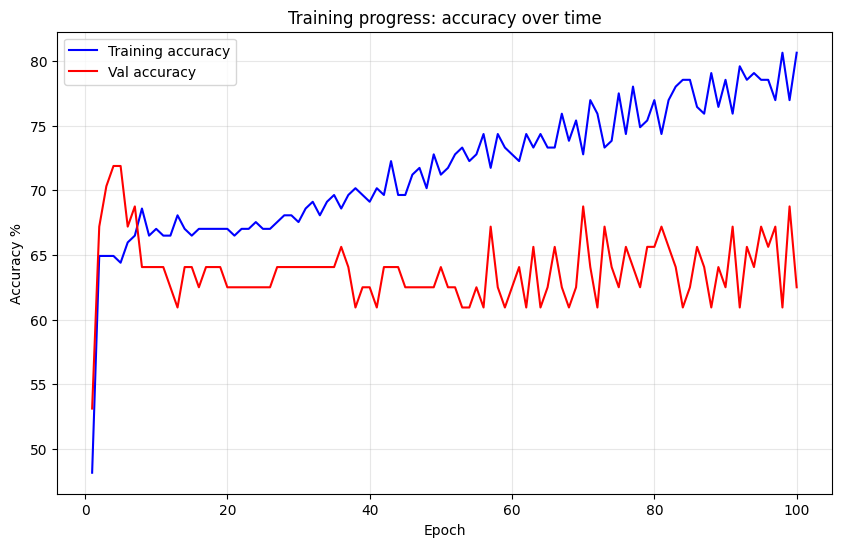

Best validation accuracy: 71.9% that was achieved at epoch 4
Final gap betweent training and validation: 18.128269910812378 percentage
large gaps suggests possible overfitting - validation accuracy much lower than training


In [ ]:
plt.figure(figsize=(10,6))
plt.plot(range(1, epochs + 1), train_accuracies, label="Training accuracy", color='blue')
plt.plot(range(1, epochs +1), val_accuracies, label="Val accuracy", color='red')
plt.xlabel('Epoch')
plt.ylabel('Accuracy %')
plt.title('Training progress: accuracy over time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_val_accuracy = max(val_accuracies)
best_epoch = val_accuracies.index(best_val_accuracy) + 1

print(f"Best validation accuracy: {best_val_accuracy:.1f}% that was achieved at epoch {best_epoch}")

final_gap = train_accuracies[-1] - val_accuracies[-1]

print(f"Final gap betweent training and validation: {final_gap} percentage")

if final_gap > 10:
  print('large gaps suggests possible overfitting - validation accuracy much lower than training')
elif final_gap < 5:
  print('small gap suggests good generalization')
else:
  print("moderate gap - model might benefit from some generalizatoin")

### Solving overfitting with regularization


In [ ]:
input_size = X_train_tensor.shape[1]

reg_model = nn.Sequential(
    nn.Linear(input_size, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.25),

    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.125),

    nn.Linear(32, 16),
    nn.ReLU(),

    nn.Linear(16, 1),
    nn.Sigmoid()
)

print("created the regularized model")
print(f"Total parameters: {sum(param.numel() for param in reg_model.parameters()):,}")
print(reg_model)

created the regularized model
Total parameters: 3,137
Sequential(
  (0): Linear(in_features=5, out_features=64, bias=True)
  (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.25, inplace=False)
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.125, inplace=False)
  (7): Linear(in_features=32, out_features=16, bias=True)
  (8): ReLU()
  (9): Linear(in_features=16, out_features=1, bias=True)
  (10): Sigmoid()
)


### A smarter training approach

Rather than simply running for 100 epochs and hoping for the best, we'll use early stopping to quit when we're ahead.


In [ ]:
criterion = nn.BCELoss()
optimizer = optim.Adam(reg_model.parameters(), lr=0.0075)

# early stopping set up
best_val_accuracy = 0
patience = 20
patience_counter = 0
best_model_state = None

reg_train_accuracies = []
reg_val_accuracies = []

print("setting up early stopping with patience of", patience)
print("training will stop if validation accuracy does not improve for", patience, "consecutive epochs")


setting up early stopping with patience of 20
training will stop if validation accuracy does not improve for 20 consecutive epochs


In [ ]:
import copy

In [ ]:
max_epochs = 100
print(f"Starting training with early stopping")

for epoch in range(max_epochs):
  reg_model.train()

  for batch_features, batch_targets in train_loader:
    optimizer.zero_grad()
    outputs = reg_model(batch_features).squeeze()
    loss = criterion(outputs, batch_targets)
    loss.backward()
    optimizer.step()

  reg_model.eval() # evaluation phase
  with torch.no_grad():

    train_outputs = reg_model(X_train_tensor).squeeze()
    train_predictions = (train_outputs > 0.5).float()
    train_accuracy = (train_predictions == y_train_tensor).float().mean().item() * 100

    # validation accuracy
    val_correct = 0
    val_total = 0

    for val_features, val_targets in val_loader:
      val_outputs = reg_model(val_features).squeeze()
      val_predictions = (val_outputs > 0.5).float()
      val_correct += (val_predictions == val_targets).sum().item()
      val_total += val_targets.size(0)

    val_accuracy = (val_correct / val_total) * 100

    # save progress
    reg_train_accuracies.append(train_accuracy)
    reg_val_accuracies.append(val_accuracy)


    # early stopping logic
    if val_accuracy > best_val_accuracy:
      best_val_accuracy = val_accuracy
      best_model_state = copy.deepcopy(reg_model.state_dict())
      patience_counter = 0
      print(f"Epoch {epoch + 1}: new best validation accuracy: {val_accuracy:.1f}%")
    else:
      patience_counter += 1

    if patience_counter > patience:
      print(f"early stopping at epoch {epoch + 1}")
      break

# load the best model that we have found
reg_model.load_state_dict(best_model_state)
print(f"loaded best model with validation accuracy: {best_val_accuracy:.1f}%")


Starting training with early stopping
Epoch 1: new best validation accuracy: 70.3%
early stopping at epoch 22
loaded best model with validation accuracy: 70.3%


### Comparing models
regularized model vs orginial overfit model

In [ ]:
print("Model Comparison:")
print("In orginal model:")
print(f"\tFinal training accuracy: {train_accuracies[-1]:.1f}%")
print(f"\tFinal validation accuracy: {val_accuracies[-1]:.1f}%")
print(f"\tGap: {train_accuracies[-1] - val_accuracies[-1]:.1f} percentage points")

print("in regularized model")
print(f"\tFinal training accuracy: {reg_train_accuracies[-1]:.1f}%")
print(f"\tFinal validation accuracy: {reg_val_accuracies[-1]:.1f}%")
print(f"\tGap: {reg_train_accuracies[-1] - reg_val_accuracies[-1]:.1f} percentage points")

improvement = reg_val_accuracies[-1] - val_accuracies[-1]
print(f"Improvement in validation accuracy: {improvement:+.1f} percentage points")

Model Comparison:
In orginal model:
	Final training accuracy: 80.6%
	Final validation accuracy: 62.5%
	Gap: 18.1 percentage points
in regularized model
	Final training accuracy: 67.5%
	Final validation accuracy: 67.2%
	Gap: 0.4 percentage points
Improvement in validation accuracy: +4.7 percentage points


### Visualizing the improvement

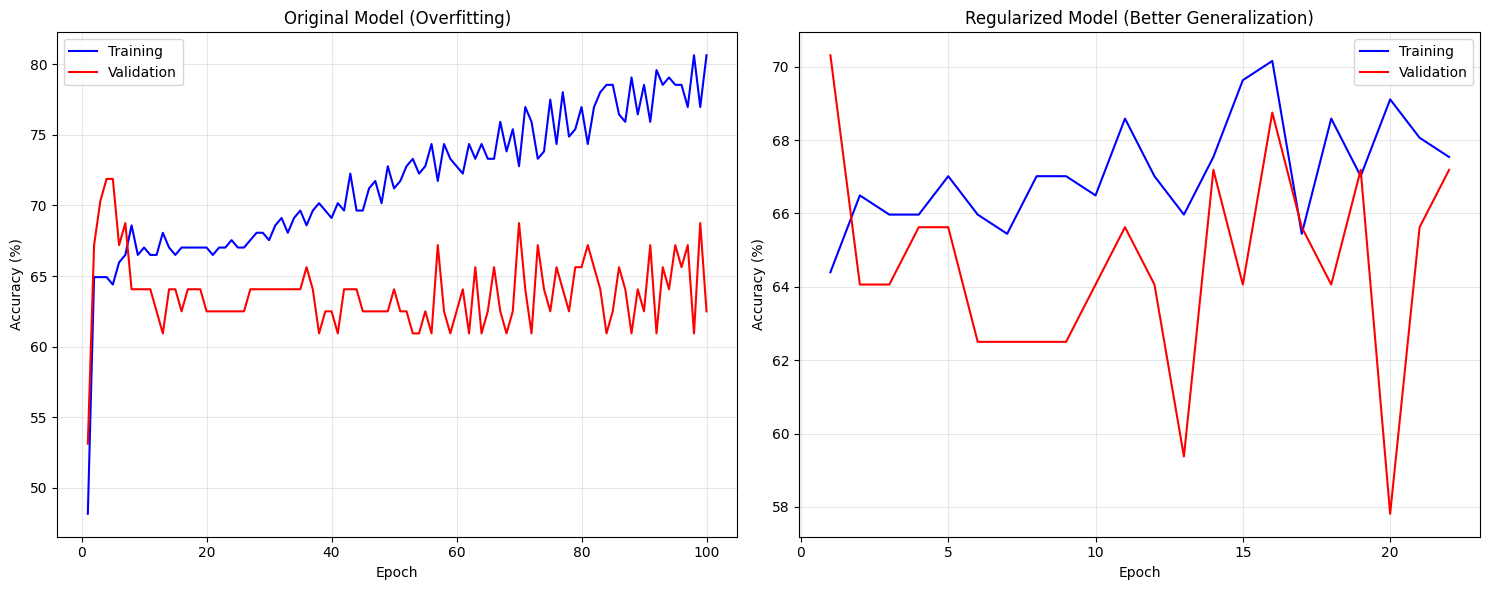

very small gap between training and validation accuracy

Our regularized model stopped early at epoch 22 instead of running the full 100 epochs
This saved us from overtraining and gave us a model that should work better on new Ipos


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Original model plot
ax1.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Training', color='blue')
ax1.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validation', color='red')
ax1.set_title('Original Model (Overfitting)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Regularized model plot
ax2.plot(range(1, len(reg_train_accuracies) + 1), reg_train_accuracies, label='Training', color='blue')
ax2.plot(range(1, len(reg_val_accuracies) + 1), reg_val_accuracies, label='Validation', color='red')
ax2.set_title('Regularized Model (Better Generalization)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final thoughts on what we achieved
final_gap = reg_train_accuracies[-1] - reg_val_accuracies[-1]
if final_gap < 5:
    print("very small gap between training and validation accuracy")
elif final_gap < 10:
    print("much better generalization than before")
else:
    print("still some overfitting exists, but significant improvement over the original model")

print(f"\nOur regularized model stopped early at epoch {len(reg_train_accuracies)} instead of running the full 100 epochs")
print("This saved us from overtraining and gave us a model that should work better on new Ipos")

### Testing with the test data (the final and actual test)

In [ ]:
reg_model.eval()

with torch.no_grad():
  test_outputs = reg_model(X_test_tensor).squeeze()
  test_predictions = (test_outputs > 0.5).float()

predicted_profitable = test_predictions.sum().item()
print(f"It predicted {int(predicted_profitable)} will be profitable and {int(len(test_predictions) - predicted_profitable)} would not")

actually_profitable = y_test_tensor.sum().item()
print(f"in reality, {int(actually_profitable)} were profitable and {int(len(y_test_tensor) - actually_profitable)} were not")


print(f"First 10 test predictions vs actual:")
for i in range(10):
    pred = "Profitable" if test_predictions[i] == 1 else "Not Profitable"
    actual = "Profitable" if y_test_tensor[i] == 1 else "Not Profitable"
    match = "✓" if test_predictions[i] == y_test_tensor[i] else "✗"
    print(f"  IPO {i+1}: Predicted {pred}, Actually {actual} {match}")

It predicted 35 will be profitable and 29 would not
in reality, 35 were profitable and 29 were not
First 10 test predictions vs actual:
  IPO 1: Predicted Profitable, Actually Profitable ✓
  IPO 2: Predicted Profitable, Actually Profitable ✓
  IPO 3: Predicted Not Profitable, Actually Not Profitable ✓
  IPO 4: Predicted Not Profitable, Actually Not Profitable ✓
  IPO 5: Predicted Profitable, Actually Profitable ✓
  IPO 6: Predicted Profitable, Actually Profitable ✓
  IPO 7: Predicted Profitable, Actually Profitable ✓
  IPO 8: Predicted Profitable, Actually Profitable ✓
  IPO 9: Predicted Not Profitable, Actually Profitable ✗
  IPO 10: Predicted Profitable, Actually Profitable ✓


### Analyzing the mistakes with a confusion matrix

In [ ]:
cm = confusion_matrix(y_test_tensor.numpy(),test_predictions.numpy())
print(cm)
tn, fp, fn, tp = cm[0,0].item(), cm[0,1].item(), cm[1,0].item(), cm[1,1].item()


print(f"true Negatives: {tn} - correctly predicted NOT profitable")
print(f"false Positives: {fp} - wrongly predicted profitable")
print(f"false Negatives: {fn} - wrongly predicted NOT profitable")
print(f"true Positives: {tp} - correctly predicted profitable")

print(f"out of {tn + fp + fn + tp} total predictions:")
print(f" got {tn + tp} right and {fp + fn} wrong")

[[17 12]
 [12 23]]
true Negatives: 17 - correctly predicted NOT profitable
false Positives: 12 - wrongly predicted profitable
false Negatives: 12 - wrongly predicted NOT profitable
true Positives: 23 - correctly predicted profitable
out of 64 total predictions:
 got 40 right and 24 wrong


### Other metrics: precision, recall

In [ ]:
precision = tp / (tp + fp)
recall = tp / (tp + fn)

print("Precision: ", precision)
print("recall ", recall)

test_accuracy = (tn + tp) / (tn + fp + fn + tp) * 100
print(f"test accuracy: {test_accuracy:.1f}%")
print(f"best validation accuracy: {best_val_accuracy:.1f}%")

accuracy_diff = abs(test_accuracy - best_val_accuracy)
print("difference in accuracy:", accuracy_diff)


Precision:  0.6571428571428571
recall  0.6571428571428571
test accuracy: 62.5%
best validation accuracy: 70.3%
difference in accuracy: 7.8125


## Training additional models to check the performance of the neural network

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

In [ ]:
from xgboost import XGBClassifier

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

### helper function

In [ ]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
  model.fit(X_train, y_train)

  preds = model.predict(X_test)
  probs = model.predict_proba(X_test)[:, 1]

  acc = accuracy_score(y_test, preds)
  precision = precision_score(y_test, preds)
  recall = recall_score(y_test, preds)
  roc_auc = roc_auc_score(y_test, probs)

  print(f"\n{name}")
  print(f"Accuracy: {acc:.3f}")
  print(f"Precision: {precision:.3f}")
  print(f"Recall: {recall:.3f}")
  print(f"ROC-AUC: {roc_auc:.3f}")

In [ ]:
for name, model in models.items():
  evaluate_model(name, model, X_train_scaled, y_train, X_test_scaled, y_test)



Logistic Regression
Accuracy: 0.625
Precision: 0.720
Recall: 0.514
ROC-AUC: 0.714

Random Forest
Accuracy: 0.609
Precision: 0.639
Recall: 0.657
ROC-AUC: 0.648

XGBoost
Accuracy: 0.609
Precision: 0.639
Recall: 0.657
ROC-AUC: 0.655


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:16:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


As we can see that logisitic regression performs better, lets save logistic regression.

In [ ]:
from sklearn.linear_model import LogisticRegression

best_model = LogisticRegression()
best_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
import pickle

with open("model.pkl", "wb") as f:
  pickle.dump(best_model, f)

with open('scaler.pkl', "wb") as f:
  pickle.dump(scaler, f)

In [ ]:
# print(best_model.predict_proba(X_test_scaled[:5]))

## Finetuning Logistic Regression Model (Hyperparameter Tuning)

- C: controls regularization strength
- penalty: L1 vs L2


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring = "roc_auc",
    n_jobs=-1 # to use all available cores
)

grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_

Best params: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Score: 0.7259570494864611


### Reevaluating

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

preds = best_model.predict(X_test_scaled)
probs = best_model.predict_proba(X_test_scaled)[:, 1] #gives prob of profitable ipo

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

Accuracy: 0.625
Precision: 0.7894736842105263
Recall: 0.42857142857142855
ROC-AUC: 0.710344827586207


## Feature engineering

Trying to find the relative subscription contribution by each group.

NOTE: adding 1e-6 to prevent zero division risk

In [ ]:
df = df_original.copy()
df["Listing_Gains_Profit"] = (df["Listing_Gains_Percent"] > 0).astype(int)

In [ ]:
df["Total_Subscription"] = df["Subscription_QIB"] + df["Subscription_HNI"] + df["Subscription_RII"]

df["QIB_to_Total"] = df["Subscription_QIB"] / (df["Total_Subscription"] + 1e-6)
df["HNI_to_Total"] = df["Subscription_HNI"] / (df["Total_Subscription"] + 1e-6)
df["RII_to_Total"] = df["Subscription_RII"] / (df["Total_Subscription"] + 1e-6)

In [ ]:
feature_columns = [
    'Subscription_QIB',
    'Subscription_HNI',
    'Subscription_RII',
    'Issue_Price',
    'Issue_Size',
    'Total_Subscription',
    'QIB_to_Total',
    'HNI_to_Total',
    'RII_to_Total'
]

X = df[feature_columns]
y = df["Listing_Gains_Profit"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

using the parameters we found in parameter tuning

In [ ]:
from sklearn.linear_model import LogisticRegression

best_model = LogisticRegression(
    C=0.1,
    penalty='l1',
    solver='liblinear',
    max_iter=1000
)

best_model.fit(X_train_scaled, y_train)

LogisticRegression(C=0.1, max_iter=1000, penalty='l1', solver='liblinear')

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

preds = best_model.predict(X_test_scaled)
probs = best_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))

Accuracy: 0.75
Precision: 0.8888888888888888
Recall: 0.5333333333333333
ROC-AUC: 0.7264705882352941


In [ ]:
### which features actually matter?

In [ ]:
import pandas as pd

coefficients = best_model.coef_[0]
features = X.columns

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
})

# key=abs sorts by absolute value
print(coef_df.sort_values(by="Coefficient", key=abs, ascending=False))

              Feature  Coefficient
0    Subscription_QIB     0.464483
2    Subscription_RII     0.127805
8        RII_to_Total    -0.025525
3         Issue_Price     0.000000
1    Subscription_HNI     0.000000
4          Issue_Size     0.000000
5  Total_Subscription     0.000000
6        QIB_to_Total     0.000000
7        HNI_to_Total     0.000000


As Subscription_QIB has highest coefficient, it means institutional demand drives IPO success.

### Creating a reusable function

In [ ]:
def run_pipeline(feature_columns):
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score


    df = df_original.copy()

    # target
    df["Listing_Gains_Profit"] = (df["Listing_Gains_Percent"] > 0).astype(int)

    # feature engineering
    df["Total_Subscription"] = df["Subscription_QIB"] + df["Subscription_HNI"] + df["Subscription_RII"]
    df["QIB_to_Total"] = df["Subscription_QIB"] / (df["Total_Subscription"] + 1e-6)
    df["HNI_to_Total"] = df["Subscription_HNI"] / (df["Total_Subscription"] + 1e-6)
    df["RII_to_Total"] = df["Subscription_RII"] / (df["Total_Subscription"] + 1e-6)

    # select features
    X = df[feature_columns]
    y = df["Listing_Gains_Profit"]

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # model
    model = LogisticRegression(
        C=0.1,
        penalty='l1',
        solver='liblinear',
        max_iter=1000
    )

    model.fit(X_train_scaled, y_train)

    # evaluate
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]

    print("Features used:", feature_columns)
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, probs))

    return model

### Simplifying the model

We will see if we can remove the useless features and still keep the performance

In [ ]:
simple_feature_columns = [
    'Subscription_QIB',
    'Subscription_RII'
]
run_pipeline(simple_feature_columns)

Features used: ['Subscription_QIB', 'Subscription_RII']
Accuracy: 0.734375
Precision: 0.8823529411764706
Recall: 0.5
ROC-AUC: 0.7558823529411764


LogisticRegression(C=0.1, max_iter=1000, penalty='l1', solver='liblinear')

we can see the performance remains.

In [ ]:
scaler = StandardScaler()
X_final = df[['Subscription_QIB', 'Subscription_RII']]
y_final = df['Listing_Gains_Profit']

X_scaled = scaler.fit_transform(X_final)

final_model = LogisticRegression(
    C=0.1,
    penalty='l1',
    solver='liblinear',
    max_iter=1000
)

final_model.fit(X_scaled, y_final)

LogisticRegression(C=0.1, max_iter=1000, penalty='l1', solver='liblinear')

In [ ]:
import pickle

pickle.dump(final_model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

### trying multiple thresholds

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

thresholds = np.arange(0.3, 0.9, 0.05)

for t in thresholds:
    preds = (probs > t).astype(int)

    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)

    print(f"Threshold: {t:.2f} | Precision: {precision:.3f} | Recall: {recall:.3f}")

Threshold: 0.30 | Precision: 0.469 | Recall: 1.000
Threshold: 0.35 | Precision: 0.469 | Recall: 1.000
Threshold: 0.40 | Precision: 0.469 | Recall: 1.000
Threshold: 0.45 | Precision: 0.636 | Recall: 0.700
Threshold: 0.50 | Precision: 0.889 | Recall: 0.533
Threshold: 0.55 | Precision: 0.929 | Recall: 0.433
Threshold: 0.60 | Precision: 0.900 | Recall: 0.300
Threshold: 0.65 | Precision: 0.833 | Recall: 0.167
Threshold: 0.70 | Precision: 0.750 | Recall: 0.100
Threshold: 0.75 | Precision: 0.500 | Recall: 0.033
Threshold: 0.80 | Precision: 0.000 | Recall: 0.000
Threshold: 0.85 | Precision: 0.000 | Recall: 0.000
Threshold: 0.90 | Precision: 0.000 | Recall: 0.000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


0.55 looks like the best choice